In [1]:
import numpy as np
import matplotlib.pyplot as plt

import utils

In [2]:
indices = range(79, 83)
names = ["omega", "kessence", "prop", "cugal"]
titles = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence-like", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like"]
aktypes = [1, 2, 4, 3]
mus_all = []

for i, (chain_index, name, aktype, color) in enumerate(zip(indices, names, aktypes, utils.colors)):
    chain = utils.load_chain(chain_index, burn_in=0.8)
    log_a, alpha_B, alpha_K, mus = utils.get_mu_alphas_from_chain(chain, aktype=aktype, num_samples=1_000)
    mus_all.append(mus)

../chains/MCMC79/MCMC79.1.txt
../chains/MCMC79/MCMC79.2.txt
../chains/MCMC79/MCMC79.3.txt
../chains/MCMC79/MCMC79.4.txt
Removed no burn in
Number of samples = 16882
Number of samples after thinning = 1056
../chains/MCMC80/MCMC80.1.txt
../chains/MCMC80/MCMC80.2.txt
../chains/MCMC80/MCMC80.3.txt
../chains/MCMC80/MCMC80.4.txt
Removed no burn in
Number of samples = 138364
Number of samples after thinning = 1003
Number of samples = 64757
Number of samples after thinning = 1012
Number of samples = 24997
Number of samples after thinning = 1042


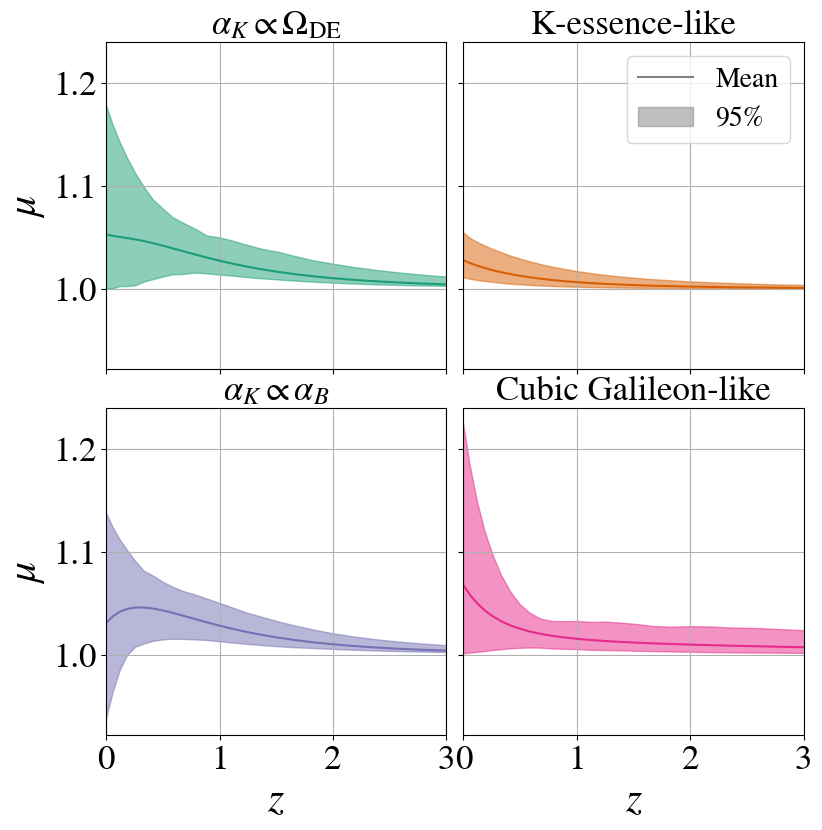

In [3]:
from importlib import reload
reload(utils)
utils.plot_mu_distribution(log_a, mus_all, "plots/constraint_mu_ds2_subluminal.pdf")

In [4]:
for chain_index, mus in zip(indices, mus_all):
    mean  = np.mean(mus, axis=0)[-1]
    upper = np.percentile(mus, 50+34, axis=0)[-1] - mean
    lower = mean - np.percentile(mus, 50-34, axis=0)[-1]
    print(f"{chain_index}: \\mu_0 ${mean:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$")

79: \mu_0 $1.05^{+0.05}_{-0.04}$
80: \mu_0 $1.03^{+0.03}_{-0.01}$
81: \mu_0 $1.03^{+0.04}_{-0.04}$
82: \mu_0 $1.07^{+0.05}_{-0.05}$
